# The Application of Physics-Informed Neural Networks (PINNS) for Geothermal Well Thermal Recovery Post-Injection Review

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

import torch
import torch.nn as nn
import torch.optim as optim
from tqdm import tqdm

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from matplotlib.patches import Circle
from matplotlib.collections import PatchCollection
import matplotlib.colors as mcolors
import matplotlib.cm as cm
from matplotlib.colors import Normalize

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# Set random seeds for reproducibility
np.random.seed(42)
torch.manual_seed(42)

Using device: cuda


## Data Wrangling

In [3]:
# Working with MXCO1 Field Data
Ti = 253.42
m = 6
tc = 2.5

In [4]:
# ==================== SCALING ====================
r_min, r_max = 0.1, 6.5
t_min, t_max = 0.0, 400
T_min, T_max = 0.0, 300.0

def scale_t(t): return (t - t_min) / (t_max - t_min)
def scale_r(r): return (r - r_min) / (r_max - r_min) * 2 - 1
def scale_T(T): return (T - T_min) / (T_max - T_min) * 2 - 1



def descale_t(t_scaled): return t_scaled * (t_max - t_min) + t_min
def descale_r(r_scaled): return (r_scaled + 1) / 2 * (r_max - r_min) + r_min
def descale_T(T_scaled): return (T_scaled + 1) / 2 * (T_max - T_min) + T_min

In [5]:
# Test the scaling functions
scale_t(400)

1.0

In [6]:
# MXCO1 Field Data
mxco1_data = {'t':[6,12,18,24,30,36],
 'r':[0.1, 0.1, 0.1, 0.1, 0.1, 0.1],
 'T':[186.3, 206.9, 219.0, 231.9, 239.8, 247.7]
}

mxco1_df = pd.DataFrame(mxco1_data)
mxco1_df.head()

,t,r,T
0,6,0.1,186.3
1,12,0.1,206.9
2,18,0.1,219.0
3,24,0.1,231.9
4,30,0.1,239.8


In [7]:
# Scale MXCO1 data
mxco1_data_scaled = {
 't': scale_t(np.array(mxco1_df['t'])),
 'r': scale_r(np.array(mxco1_df['r'])),
 'T': scale_T(np.array(mxco1_df['T']))
}

t_data = mxco1_data_scaled['t']
r_data = mxco1_data_scaled['r']
T_data = mxco1_data_scaled['T']
mxco1_df_scaled = pd.DataFrame(mxco1_data_scaled)
mxco1_df_scaled.head()

,t,r,T
0,0.015,-1.0,0.242000
1,0.030,-1.0,0.379333
2,0.045,-1.0,0.460000
3,0.060,-1.0,0.546000
4,0.075,-1.0,0.598667


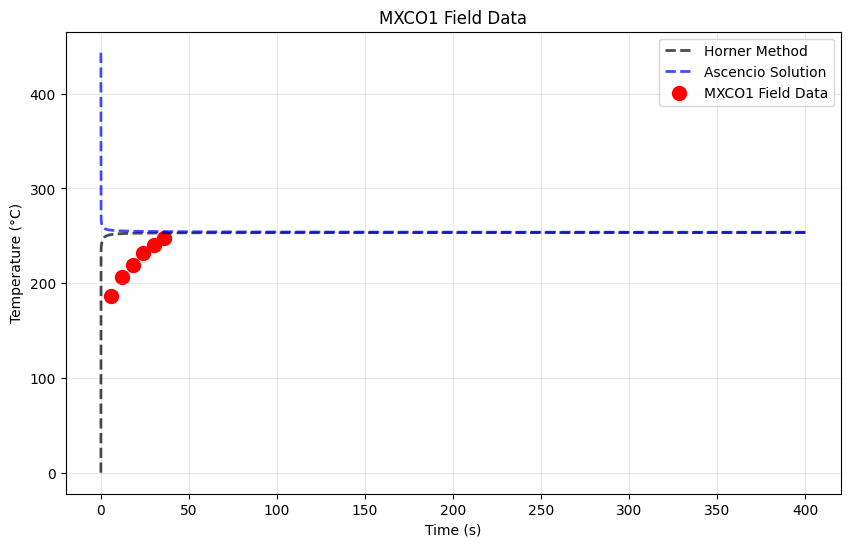

In [8]:
# Analytical Solutions for comparison
Th = lambda dt: Ti - m * np.log((tc + dt) / (dt))
Ta = lambda t: Ti + 1/np.sqrt(t) * m
time_data = np.logspace(np.log10(0.1), np.log10(400), 50)
Th_data = Th(time_data)
Ta_data = Ta(time_data)




plt.figure(figsize=(10, 6))
plt.plot(np.append(0, time_data), np.append(0, Th_data), 'k--', linewidth=2, alpha=0.7, label='Horner Method')
plt.plot(np.append(0, time_data), np.append(Ta(1e-3), Ta_data), 'b--', linewidth=2, alpha=0.7, label='Ascencio Solution')
plt.scatter(mxco1_df['t'], mxco1_df['T'], color='red', s=100, label='MXCO1 Field Data')
plt.xlabel('Time (s)')
plt.ylabel('Temperature (°C)')
plt.title('MXCO1 Field Data')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [9]:
# Convert data to PyTorch tensors
t_data_tensor = torch.tensor(mxco1_df_scaled['t'].values.reshape(-1, 1), dtype=torch.float32).to(device)

r_data_tensor = torch.tensor(mxco1_df_scaled['r'].values.reshape(-1, 1), dtype=torch.float32).to(device)

T_data_tensor = torch.tensor(mxco1_df_scaled['T'].values.reshape(-1, 1), dtype=torch.float32).to(device)

In [10]:
# Collocation Points for PINN
n_colloc = 50

t_pde_raw = torch.linspace(0, 1, n_colloc).reshape(-1,1)
r_pde_raw = torch.linspace(-1, 1, n_colloc).reshape(-1,1)
r_pde_grid, t_pde_grid = torch.meshgrid(r_pde_raw.squeeze(), t_pde_raw.squeeze(), indexing='ij')
t_colloc = t_pde_grid.flatten().reshape(-1,1).to(device)
r_colloc = r_pde_grid.flatten().reshape(-1,1).to(device)

## Model Development

In [11]:
class SimpleNN(nn.Module):
    """Standard feedforward neural network"""
    def __init__(self, hidden_size=20, n_layers=8, initial_alpha=1.33e-6):
        super().__init__()
        
        layers = []
        layers.append(nn.Linear(2, hidden_size))  # Input: (r, t)
        
        # Hidden layers
        for _ in range(n_layers):
            layers.append(nn.Tanh())  # Smooth activation (important!)
            layers.append(nn.Linear(hidden_size, hidden_size))
        
        layers.append(nn.Tanh())
        layers.append(nn.Linear(hidden_size, 1))  # Output: temperature T
        
        self.network = nn.Sequential(*layers)

        # Initialize alpha as a learnable parameter with a starting value
        self.alpha = nn.Parameter(torch.tensor(initial_alpha, dtype=torch.float32, requires_grad=True))
    
    def forward(self, x):
        return self.network(x)


print("Data shapes:")
print(f"  Training: {mxco1_df_scaled[['t']].shape}, {mxco1_df_scaled[['r']].shape} -> {mxco1_df_scaled[['T']].shape}")


Data shapes:
  Training: (6, 1), (6, 1) -> (6, 1)


In [12]:
# Set random seeds for reproducibility
np.random.seed(42)
torch.manual_seed(42)

def train_standardNN(model, t_data, r_data, T_data, epochs=15000, lr=1e-3):#6e-5
    """
    Train a Physics-Informed Neural Network
    
    Args:
        model: Neural network
        t_data, r_data, T_data: Training data points
        epochs: Number of training epochs
        lr: Learning rate"""
    optimizer = optim.Adam(model.parameters(), lr=lr)
    criterion = nn.MSELoss()
    
    # Storage for loss history
    losses = []
    

    pbar = tqdm(range(epochs), desc="Training PINN")
    for epoch in pbar:
        optimizer.zero_grad()
        
        # Loss: how well do we fit the measurements?
        T_pred_data = model(torch.cat([t_data, r_data], dim=1))
        loss = criterion(T_pred_data, T_data)

        # Backpropagation
        loss.backward()
        optimizer.step()
        
        # Store losses
        losses.append(loss.item())

        
        if (epoch + 1) % 2000 == 0:
            pbar.set_postfix({'Loss': f'{loss.item():.6f}'})
        
    return losses

In [13]:
# Set random seeds for reproducibility
np.random.seed(42)
torch.manual_seed(42)

def physics_loss(model, t_colloc, r_colloc):
    """Compute the physics-based loss for the steady-state heat conduction problem"""
    # Enable gradients for collocation points
    # Ensure gradients are enabled for input
    r_colloc = r_colloc.clone().detach().to(device).requires_grad_(True)
    t_colloc = t_colloc.clone().detach().to(device).requires_grad_(True)


    # Predict temperature
    T_pred = model(torch.cat([t_colloc, r_colloc], dim=1))

    # First derivative
    dT_dr = torch.autograd.grad(outputs=T_pred, 
                            inputs=r_colloc, 
                            grad_outputs=torch.ones_like(T_pred), 
                            create_graph=True,
                            retain_graph=True)[0]
    
    dT_dt = torch.autograd.grad(outputs=T_pred, 
                            inputs=t_colloc,
                            grad_outputs=torch.ones_like(T_pred),
                            create_graph=True,
                            retain_graph=True)[0]

    # Second derivative
    d2T_dr2 = torch.autograd.grad(outputs=dT_dr, 
                               inputs=r_colloc, 
                               grad_outputs=torch.ones_like(dT_dr), 
                               create_graph=True,
                               retain_graph=True)[0]


    # Physics residual: d2T/dr2 + q/k = 0
    Dt = 1.33e-6
    # residual = (1/model.alpha) * dT_dt - d2T_dr2 - (1/r_colloc) * dT_dr
    residual = (1/Dt) * dT_dt - d2T_dr2 - (1/r_colloc) * dT_dr

    # Mean squared residual
    phys_loss = torch.mean(residual**2)
    
    return phys_loss

# Test the physics loss function
test_model = SimpleNN().to(device)

test_loss = physics_loss(test_model, t_colloc, r_colloc)

print(f"Physics loss (untrained model): {test_loss.item():.6f}")
print("This is large since the model hasn't learned the physics yet!")
#208871.453125

Physics loss (untrained model): 208871.453125
This is large since the model hasn't learned the physics yet!


c:\Users\emman\anaconda3\Lib\site-packages\torch\autograd\graph.py:823: UserWarning: Attempting to run cuBLAS, but there was no current CUDA context! Attempting to set the primary context... (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\aten\src\ATen\cuda\CublasHandlePool.cpp:180.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


In [14]:
# Set random seeds for reproducibility
np.random.seed(42)
torch.manual_seed(42)

def boundary_loss(model, T_bndry, n_colloc, r_bndry=6.5):
    """Compute the boundary condition loss"""
    t_bndry = torch.linspace(0, 1, n_colloc).reshape(-1,1).to(device)
    r_bndry = torch.full((n_colloc, 1), 1.0).reshape(-1,1).to(device)
    T_bndry = torch.full((n_colloc, 1), scale_T(T_bndry)).reshape(-1,1).to(device)
    T_pred_bndry = model(torch.cat([t_bndry, r_bndry], dim=1))
    bndry_loss = torch.mean((T_pred_bndry - T_bndry)**2)
    return bndry_loss


# Test the boundary loss function
test_model = SimpleNN().to(device)
test_loss = boundary_loss(test_model, Ti, n_colloc)

print(f"Boundary loss (untrained model): {test_loss.item():.6f}")
print("This is large since the model hasn't learned the physics yet!")

Boundary loss (untrained model): 0.552641
This is large since the model hasn't learned the physics yet!


In [15]:
# Set random seeds for reproducibility
np.random.seed(42)
torch.manual_seed(42)

def train_pinn(model, t_colloc, r_colloc, Ti, epochs=15000, lr=1e-3, lambda_physics= 1, lambda_boundary=1, adaptive_lambda=False, adaptive_rate=0.01):
    """
    Train a Physics-Informed Neural Network
    
    Args:
        model: Neural network
        t_colloc, r_colloc: Collocation points for physics
        Ti: Physical parameters
        epochs: Number of training epochs
        lr: Learning rate
        lambda_physics: Balance parameter between data and physics
        lambda_boundary: Balance parameter for boundary conditions
    """
    optimizer = optim.Adam(model.parameters(), lr=lr)
    
    # Storage for loss history
    physics_losses = []
    boundary_losses = []
    total_losses = []
    lambda_pde = []
    lambda_bc = []
    
    print(f"Training PINN with λ = {lambda_physics}")
    print(f"Collocation points: {len(t_colloc)}")

    pbar = tqdm(range(epochs), desc="Training PINN")
    for epoch in pbar:
        optimizer.zero_grad()

        # Physics loss: how well do we satisfy the ODE?
        loss_physics = physics_loss(model, t_colloc, r_colloc)

        # Boundary loss: how well do we satisfy the boundary conditions?
        loss_boundary = boundary_loss(model, Ti, n_colloc)

        # Total loss: balance data fitting and physics
        #total_loss = loss_data + lambda_physics * loss_physics
        total_loss =  lambda_boundary * loss_boundary  +  lambda_physics * loss_physics
        
        # Backpropagation
        total_loss.backward()
        optimizer.step()

        if adaptive_lambda:

            # Detach to remove from computation graph
            loss_physics_val = loss_physics.item()
            loss_boundary_val = loss_boundary.item()
            
            # Update both lambda values based on their respective losses
            lambda_physics += (adaptive_rate * loss_physics_val * 100 * 
                            np.exp(-lambda_physics) / (1 + np.exp(-lambda_physics))**2)
            lambda_boundary += (adaptive_rate * loss_boundary_val * 100 *
                        np.exp(-lambda_boundary) / (1 + np.exp(-lambda_boundary))**2)
            
            

        
        # Store losses
        physics_losses.append(loss_physics.item())
        boundary_losses.append(loss_boundary.item())
        total_losses.append(total_loss.item())
        lambda_pde.append(lambda_physics)
        lambda_bc.append(lambda_boundary)
        
        if (epoch + 1) % 2000 == 0:
            pbar.set_postfix({'Physics': f'{loss_physics.item():.6f}',
                              'Boundary': f'{loss_boundary.item():.6f}',
                              'Total': f'{total_loss.item():.6f}',
                              'λ_pde': f'{lambda_physics:.6f}',
                              'λ_bc': f'{lambda_boundary:.6f}'
                              })
        
    return physics_losses, boundary_losses, total_losses, lambda_pde, lambda_bc

Collocation points: uniformly distributed in [0, 40] along time axis
Physics weight λ = 1e-15 (typically much smaller than 1)
Boundary weight λ = 0.001 (typically much smaller than 1)
Data weight λ = 1 (typically much smaller than 1)


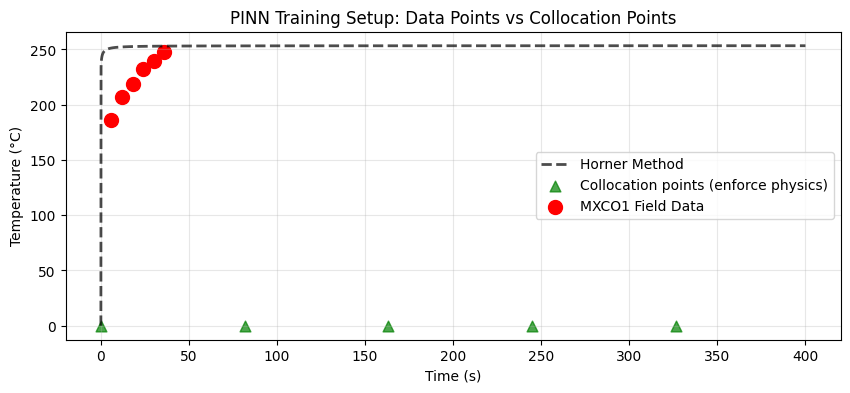

In [16]:
# Set random seeds for reproducibility
np.random.seed(42)
torch.manual_seed(42)

def train_pinn_data(model, t_data, r_data, T_data, t_colloc, r_colloc, Ti, 
               epochs=15000, lr=1e-3, lambda_data = 1, lambda_physics = 1e-15, lambda_boundary = 1e-3,
               adaptive_lambda=False, adaptive_rate=0.01):#6e-5
    """
    Train a Physics-Informed Neural Network
    
    Args:
        model: Neural network
        t_data, r_data, T_data: Training data points
        t_colloc, r_colloc: Collocation points for physics
        Ti: Physical parameters
        lambda_physics: Balance parameter between data and physics
    """
    optimizer = optim.Adam(model.parameters(), lr=lr)
    criterion = nn.MSELoss()
    
    # Storage for loss history
    data_losses = []
    physics_losses = []
    boundary_losses = []
    total_losses = []
    lambda_d = []
    lambda_pde = []
    lambda_bc = []
    
    print(f"Training PINN with λ = {lambda_physics}")
    print(f"Data points: {len(t_data)}, Collocation points: {len(t_colloc)}")

    pbar = tqdm(range(epochs), desc="Training PINN")
    for epoch in pbar:
        optimizer.zero_grad()
        
        # Data loss: how well do we fit the measurements?
        T_pred_data = model(torch.cat([t_data, r_data], dim=1))
        loss_data = criterion(T_pred_data, T_data)

        # Physics loss: how well do we satisfy the ODE?
        loss_physics = physics_loss(model, t_colloc, r_colloc)

        # Boundary loss: how well do we satisfy the boundary conditions?
        loss_boundary = boundary_loss(model, Ti, n_colloc)

        # Total loss: balance data fitting and physics
        total_loss =  lambda_data * loss_data  +  lambda_boundary * loss_boundary  +  lambda_physics * loss_physics
        
        # Backpropagation
        total_loss.backward()
        optimizer.step()

        if adaptive_lambda:

            # Detach to remove from computation graph
            loss_physics_val = loss_physics.item()
            loss_boundary_val = loss_boundary.item()
            loss_data_val = loss_data.item()
            
            # Update both lambda values based on their respective losses
            lambda_physics += (adaptive_rate * loss_physics_val * 100 * 
                            np.exp(-lambda_physics) / (1 + np.exp(-lambda_physics))**2)
            lambda_boundary += (adaptive_rate * loss_boundary_val * 100 *
                        np.exp(-lambda_boundary) / (1 + np.exp(-lambda_boundary))**2)
            lambda_data += (adaptive_rate * loss_data_val * 100 *
                        np.exp(-lambda_data) / (1 + np.exp(-lambda_data))**2)
        
        # Store losses
        data_losses.append(loss_data.item())
        physics_losses.append(loss_physics.item())
        boundary_losses.append(loss_boundary.item())
        total_losses.append(total_loss.item())
        lambda_pde.append(lambda_physics)
        lambda_bc.append(lambda_boundary)
        lambda_d.append(lambda_data)
        
        if (epoch + 1) % 2000 == 0:
            pbar.set_postfix({'Loss': f'{loss_data.item():.6f}', 
                              'Physics': f'{loss_physics.item():.6f}',
                              'Boundary': f'{loss_boundary.item():.6f}',
                              'Total': f'{total_loss.item():.6f}',
                              'λ_data': f'{lambda_data:.6f}',
                              'λ_pde': f'{lambda_physics:.6f}',
                              'λ_bc': f'{lambda_boundary:.6f}'})
        
    return data_losses, physics_losses, boundary_losses, total_losses, lambda_d, lambda_pde, lambda_bc


    # Setup for PINN training
lambda_physics = 1e-15  # Balance parameter
lambda_boundary = 1e-3  # Balance parameter for boundary conditions
lambda_data = 1  # Balance parameter for data fitting

print(f"Collocation points: uniformly distributed in [0, 40] along time axis")
print(f"Physics weight λ = {lambda_physics} (typically much smaller than 1)")
print(f"Boundary weight λ = {lambda_boundary} (typically much smaller than 1)")
print(f"Data weight λ = {lambda_data} (typically much smaller than 1)")
# Visualize training setup
plt.figure(figsize=(10, 4))
plt.plot(np.append(0, time_data), np.append(0, Th_data), 'k--', linewidth=2, alpha=0.7, label='Horner Method')
plt.scatter(descale_t(t_pde_raw)[::10], np.zeros(len(t_pde_raw[::10])), 
            color='green', marker='^', s=60, alpha=0.7, label='Collocation points (enforce physics)')

plt.scatter(mxco1_df['t'], mxco1_df['T'], color='red', s=100, label='MXCO1 Field Data')

plt.xlabel('Time (s)')
plt.ylabel('Temperature (°C)')
plt.title('PINN Training Setup: Data Points vs Collocation Points')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## Model Training

In [17]:
# Setup for PINN training
lambda_physics = 1e-4  # Balance parameter
lambda_boundary = 1e-3  # Balance parameter for boundary conditions

print(f"Collocation points: uniformly distributed along time and radius axis")
print(f"Physics weight λ = {lambda_physics} (typically much smaller than 1)")
print(f"Boundary weight λ = {lambda_boundary} (typically much smaller than 1)")

Collocation points: uniformly distributed along time and radius axis
Physics weight λ = 0.0001 (typically much smaller than 1)
Boundary weight λ = 0.001 (typically much smaller than 1)


### Data Based Model

In [18]:
# Set random seeds for reproducibility
np.random.seed(42)
torch.manual_seed(42)

# Create a fresh StandardNN model
data_model = SimpleNN().to(device)

# Train the StandardNN
losses_SNN = train_standardNN(
    data_model, t_data_tensor, r_data_tensor, T_data_tensor
)

Training PINN: 100%|██████████| 15000/15000 [00:30<00:00, 488.12it/s, Loss=0.000007]


In [19]:
# Make predictions
with torch.no_grad():
    r_data_test = torch.tensor(scale_r(torch.tensor([0.1] * n_colloc))).reshape(-1, 1).to(device)
    t_data_test = torch.tensor(t_pde_raw).reshape(-1, 1).to(device)
    T_pred_data = data_model(torch.cat([t_data_test, r_data_test], dim=1)).detach().cpu().numpy().flatten()

print(f"StandardNN Training Complete!")
print(f"Final data loss: {losses_SNN[-1]:.6f}")

StandardNN Training Complete!
Final data loss: 0.000006


C:\Users\emman\AppData\Local\Temp\ipykernel_19484\3469853501.py:3: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  r_data_test = torch.tensor(scale_r(torch.tensor([0.1] * n_colloc))).reshape(-1, 1).to(device)
C:\Users\emman\AppData\Local\Temp\ipykernel_19484\3469853501.py:4: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  t_data_test = torch.tensor(t_pde_raw).reshape(-1, 1).to(device)


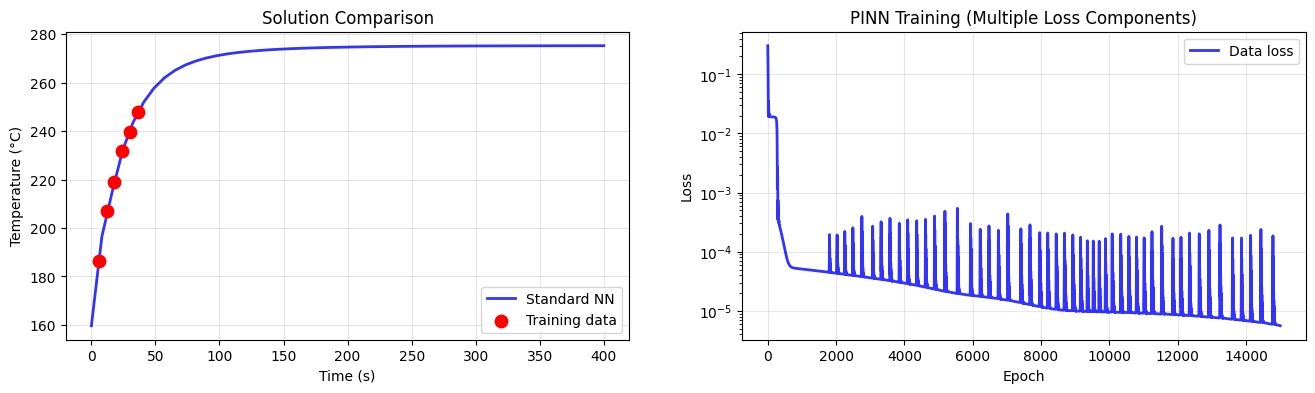

In [20]:
# Compare Standard NN vs PINN
fig, axes = plt.subplots(1, 2, figsize=(16, 4))

# Plot 1: Solutions comparison
ax = axes[0]
ax.plot(descale_t(t_data_test.detach().cpu().numpy().flatten()), descale_T(T_pred_data), 'b-', linewidth=2, label='Standard NN', alpha=0.8)
ax.scatter(descale_t(t_data), descale_T(T_data), color='red', s=80, zorder=5, label='Training data')
ax.set_xlabel('Time (s)')
ax.set_ylabel('Temperature (°C)')
ax.set_title('Solution Comparison')
ax.legend()
ax.grid(True, alpha=0.3)

# Plot 2: Loss evolution for PINN
ax = axes[1]
ax.plot(losses_SNN, 'b-', linewidth=2, label='Data loss', alpha=0.8)
ax.set_xlabel('Epoch')
ax.set_ylabel('Loss')
ax.set_title('PINN Training (Multiple Loss Components)')
ax.set_yscale('log')
ax.legend()
ax.grid(True, alpha=0.3)

### PINN Model

In [21]:
# Set random seeds for reproducibility
np.random.seed(42)
torch.manual_seed(42)

# Create a fresh PINN model
pinn_model = SimpleNN().to(device)

# Train the PINN
physics_losses_pinn, boundary_losses_pinn, total_losses_pinn, lambda_pde_pinn, lambda_bc_pinn = train_pinn(
    pinn_model, t_colloc, r_colloc, Ti, lambda_physics= 1, lambda_boundary=1e-10, adaptive_lambda=True
    )

Training PINN with λ = 1
Collocation points: 2500


Training PINN: 100%|██████████| 15000/15000 [02:29<00:00, 100.09it/s, Physics=0.017052, Boundary=0.000000, Total=700.281860, λ_pde=41067.620198, λ_bc=4.814954]


In [22]:
# Make predictions
with torch.no_grad():
    r_pinn_test = torch.tensor(scale_r(torch.tensor([0.1] * n_colloc))).reshape(-1, 1).to(device)
    t_pinn_test = torch.tensor(t_pde_raw).reshape(-1, 1).to(device)
    T_pred_pinn = pinn_model(torch.cat([t_pinn_test, r_pinn_test], dim=1)).detach().cpu().numpy().flatten()

print(f"PINN Training Complete!")
print(f"Final physics loss: {physics_losses_pinn[-1]:.6f}")
print(f"Final boundary loss: {boundary_losses_pinn[-1]:.6f}")
print(f"Final total loss: {total_losses_pinn[-1]:.6f}")

PINN Training Complete!
Final physics loss: 0.004387
Final boundary loss: 0.000000
Final total loss: 180.158203


C:\Users\emman\AppData\Local\Temp\ipykernel_19484\2667928502.py:3: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  r_pinn_test = torch.tensor(scale_r(torch.tensor([0.1] * n_colloc))).reshape(-1, 1).to(device)
C:\Users\emman\AppData\Local\Temp\ipykernel_19484\2667928502.py:4: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  t_pinn_test = torch.tensor(t_pde_raw).reshape(-1, 1).to(device)


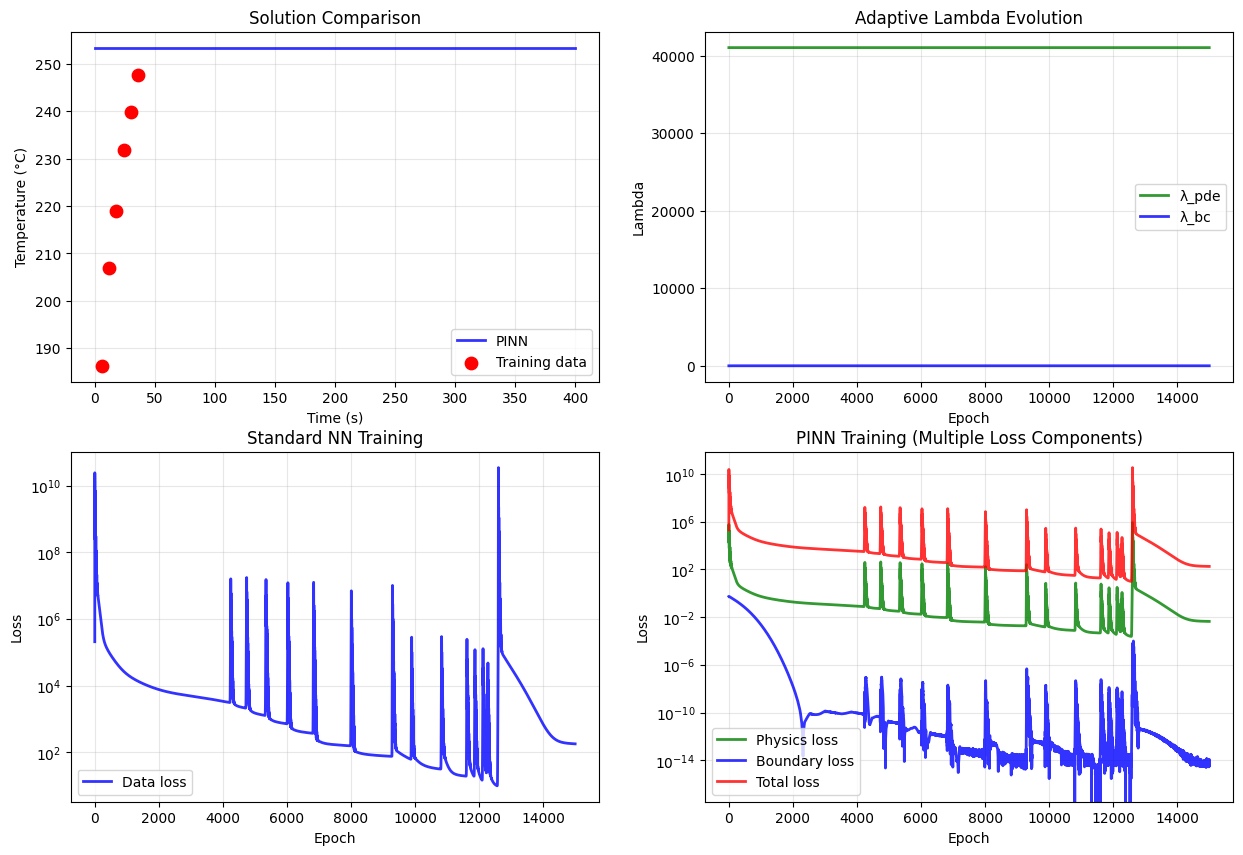

In [23]:
# Compare Standard NN vs PINN
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Plot 1: Solutions comparison
ax = axes[0, 0]
ax.plot(descale_t(t_pinn_test.detach().cpu().numpy().flatten()), descale_T(T_pred_pinn), 'b-', linewidth=2, label='PINN', alpha=0.8)
ax.scatter(descale_t(t_data), descale_T(T_data), color='red', s=80, zorder=5, label='Training data')
ax.set_xlabel('Time (s)')
ax.set_ylabel('Temperature (°C)')
ax.set_title('Solution Comparison')
ax.legend()
ax.grid(True, alpha=0.3)


# Plot 2: Lambda evolution for PINN
ax = axes[0, 1]
ax.plot(lambda_pde_pinn, 'g-', linewidth=2, label='λ_pde', alpha=0.8)
ax.plot(lambda_bc_pinn, 'b-', linewidth=2, label='λ_bc', alpha=0.8)
ax.set_xlabel('Epoch')
ax.set_ylabel('Lambda')
ax.set_title('Adaptive Lambda Evolution')
ax.legend()
ax.grid(True, alpha=0.3)

# Plot 2: Loss evolution for PINN
ax = axes[1, 0]
ax.plot(total_losses_pinn, 'b-', linewidth=2, label='Data loss', alpha=0.8)
ax.set_xlabel('Epoch')
ax.set_ylabel('Loss')
ax.set_title('Standard NN Training')
ax.set_yscale('log')
ax.legend()
ax.grid(True, alpha=0.3)


# Plot 4: Loss evolution for PINN
ax = axes[1, 1]
ax.plot(physics_losses_pinn, 'g-', linewidth=2, label='Physics loss', alpha=0.8)
ax.plot(boundary_losses_pinn, 'b-', linewidth=2, label='Boundary loss', alpha=0.8)
ax.plot(total_losses_pinn, 'r-', linewidth=2, label='Total loss', alpha=0.8)
ax.set_xlabel('Epoch')
ax.set_ylabel('Loss')
ax.set_title('PINN Training (Multiple Loss Components)')
ax.set_yscale('log')
ax.legend()
ax.grid(True, alpha=0.3)

### PINN + Data Model

In [82]:
# Set random seeds for reproducibility
np.random.seed(42)
torch.manual_seed(42)

# Create a fresh PINN model
pinn_data_model = SimpleNN().to(device)

# Train the PINN
data_losses_pinn_data, physics_losses_pinn_data, boundary_losses_pinn_data, total_losses_pinn_data, lambda_d_pinn_data, lambda_pde_pinn_data, lambda_bc_pinn_data = train_pinn_data(
    pinn_data_model, t_data_tensor, r_data_tensor, T_data_tensor, t_colloc, r_colloc, Ti,
    lambda_data = 5, lambda_physics = 5e-14, lambda_boundary = 1, adaptive_lambda=False, adaptive_rate=0.01
    )

Training PINN with λ = 5e-14
Data points: 6, Collocation points: 2500


Training PINN: 100%|██████████| 15000/15000 [02:46<00:00, 89.85it/s, Loss=0.000039, Physics=33034844160.000000, Boundary=0.000000, Total=0.001846, λ_data=5.000000, λ_pde=0.000000, λ_bc=1.000000]


In [95]:
# Make predictions
with torch.no_grad():
    r_pinn_data_test = torch.tensor(scale_r(torch.tensor([0.1] * n_colloc))).reshape(-1, 1).to(device)
    t_pinn_data_test = torch.tensor(t_pde_raw).reshape(-1, 1).to(device)
    T_pred_pinn_data = pinn_data_model(torch.cat([t_pinn_data_test, r_pinn_data_test], dim=1)).detach().cpu().numpy().flatten()

print(f"PINN Training Complete!")
print(f"Final data loss: {data_losses_pinn_data[-1]:.6f}")
print(f"Final physics loss: {physics_losses_pinn_data[-1]:.6f}")
print(f"Final boundary loss: {boundary_losses_pinn_data[-1]:.6f}")
print(f"Final total loss: {total_losses_pinn_data[-1]:.6f}")

PINN Training Complete!
Final data loss: 0.000057
Final physics loss: 32106311680.000000
Final boundary loss: 0.000000
Final total loss: 0.001891


C:\Users\emman\AppData\Local\Temp\ipykernel_19484\612444198.py:3: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  r_pinn_data_test = torch.tensor(scale_r(torch.tensor([0.1] * n_colloc))).reshape(-1, 1).to(device)
C:\Users\emman\AppData\Local\Temp\ipykernel_19484\612444198.py:4: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  t_pinn_data_test = torch.tensor(t_pde_raw).reshape(-1, 1).to(device)


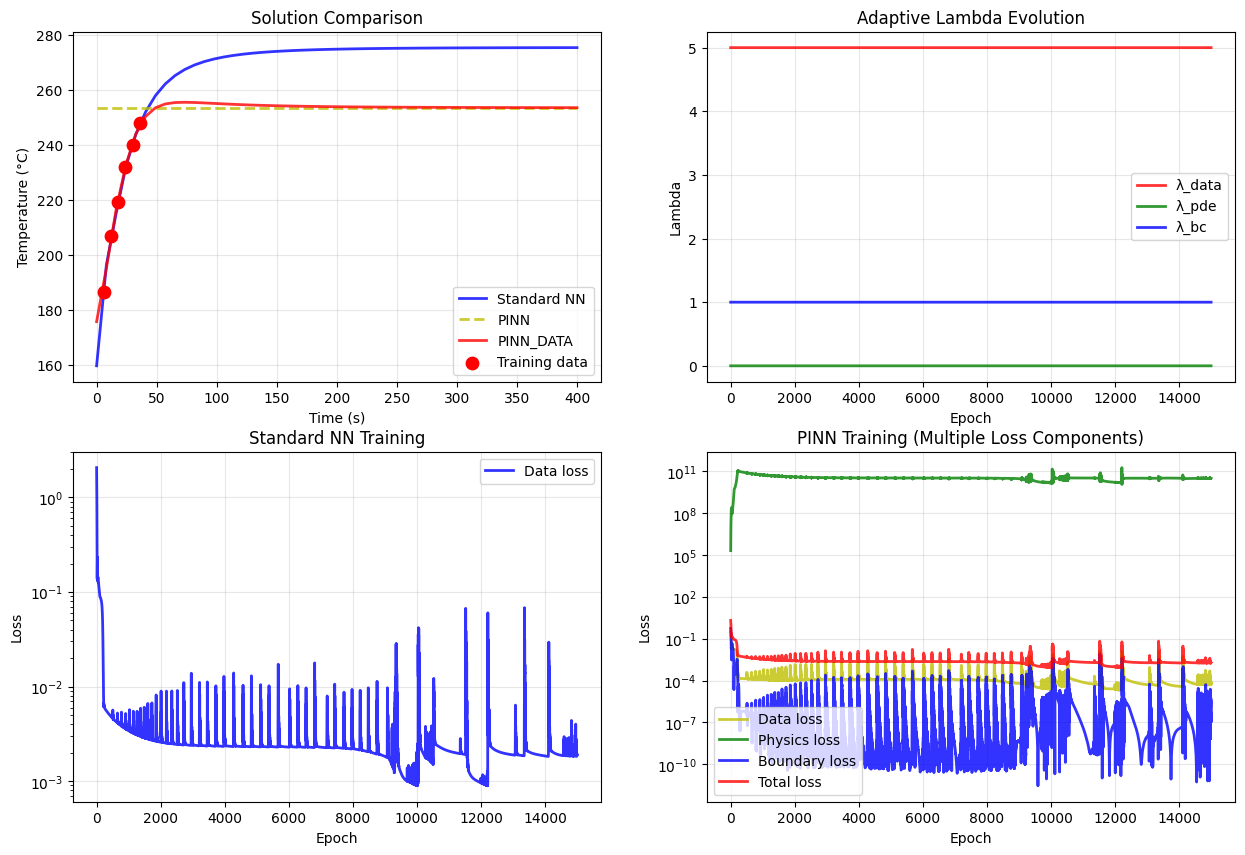

In [96]:
# Compare Standard NN vs PINN
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Plot 1: Solutions comparison
ax = axes[0, 0]
ax.plot(descale_t(t_data_test.detach().cpu().numpy().flatten()), descale_T(T_pred_data), 'b-', linewidth=2, label='Standard NN', alpha=0.8)
ax.plot(descale_t(t_pinn_test.detach().cpu().numpy().flatten()), descale_T(T_pred_pinn), 'y--', linewidth=2, label='PINN', alpha=0.8)
ax.plot(descale_t(t_pinn_data_test.detach().cpu().numpy().flatten()), descale_T(T_pred_pinn_data), 'r-', linewidth=2, label='PINN_DATA', alpha=0.8)
ax.scatter(descale_t(t_data), descale_T(T_data), color='red', s=80, zorder=5, label='Training data')
ax.set_xlabel('Time (s)')
ax.set_ylabel('Temperature (°C)')
ax.set_title('Solution Comparison')
ax.legend()
ax.grid(True, alpha=0.3)


# Plot 2: Lambda evolution for PINN
ax = axes[0, 1]
ax.plot(lambda_d_pinn_data, 'r-', linewidth=2, label='λ_data', alpha=0.8)
ax.plot(lambda_pde_pinn_data, 'g-', linewidth=2, label='λ_pde', alpha=0.8)
ax.plot(lambda_bc_pinn_data, 'b-', linewidth=2, label='λ_bc', alpha=0.8)
ax.set_xlabel('Epoch')
ax.set_ylabel('Lambda')
ax.set_title('Adaptive Lambda Evolution')
ax.legend()
ax.grid(True, alpha=0.3)

# Plot 2: Loss evolution for PINN
ax = axes[1, 0]
ax.plot(total_losses_pinn_data, 'b-', linewidth=2, label='Data loss', alpha=0.8)
ax.set_xlabel('Epoch')
ax.set_ylabel('Loss')
ax.set_title('Standard NN Training')
ax.set_yscale('log')
ax.legend()
ax.grid(True, alpha=0.3)


# Plot 4: Loss evolution for PINN
ax = axes[1, 1]
ax.plot(data_losses_pinn_data, 'y-', linewidth=2, label='Data loss', alpha=0.8)
ax.plot(physics_losses_pinn_data, 'g-', linewidth=2, label='Physics loss', alpha=0.8)
ax.plot(boundary_losses_pinn_data, 'b-', linewidth=2, label='Boundary loss', alpha=0.8)
ax.plot(total_losses_pinn_data, 'r-', linewidth=2, label='Total loss', alpha=0.8)
ax.set_xlabel('Epoch') 
ax.set_ylabel('Loss')
ax.set_title('PINN Training (Multiple Loss Components)')
ax.set_yscale('log')
ax.legend()
ax.grid(True, alpha=0.3)

####################################
# Dear future me, adjust the phycis loss to be lower, that is reduce negative vale

In [85]:
max(descale_T(T_pred_pinn_data)), Ti

(255.40268, 253.42)

## Temperature Profile Development

In [86]:
# -------------------------------------------------
# Radial and time points for plotting
# 2. INPUT: Timesteps and Radii
# -------------------------------------------------
t_list = [6, 12, 36, 200]        # hours
r_list = [0.1, 1.0, 2.0, 4.0, 6.5]  # meters

In [87]:


# -------------------------------------------------
# 3. PREDICT TEMPERATURE AT EACH (r, t)
# -------------------------------------------------
with torch.no_grad():
    T_pred_dict = {}
    for t_val in t_list:
        T_at_t = []
        for r_val in r_list:
            r_in = scale_r(torch.tensor([[r_val]])).to(next(pinn_data_model.parameters()).device)
            t_in = scale_t(torch.tensor([[t_val]])).to(next(pinn_data_model.parameters()).device)
            x_in = torch.cat([t_in, r_in], dim=1)
            T_scaled = pinn_data_model(x_in)
            T_real = descale_T(T_scaled.cpu()).item()
            T_at_t.append(T_real)
        T_pred_dict[t_val] = T_at_t

C:\Users\emman\AppData\Local\Temp\ipykernel_19484\1973283326.py:40: UserWarning: tight_layout not applied: number of columns in subplot specifications must be multiples of one another.
  plt.tight_layout()


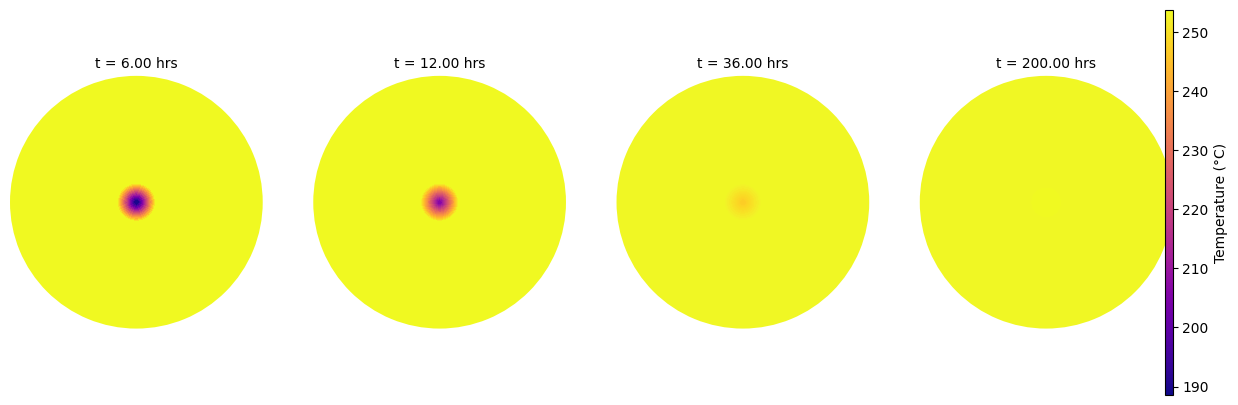

In [88]:
# Create a radial grid
theta = np.linspace(0, 2*np.pi, 200)
r = np.linspace(0, max(r_list), 200)
R, TH = np.meshgrid(r, theta)

# Determine common temperature range
all_T_values = np.concatenate([T_pred_dict[t] for t in t_list])
vmin, vmax = all_T_values.min(), all_T_values.max()
norm = Normalize(vmin=vmin, vmax=vmax)          # <-- shared normalisation

# Plot for each timestep
fig, axes = plt.subplots(1, len(t_list), figsize=(15, 5), subplot_kw={'projection': 'polar'})

contours = []
for ax, t in zip(axes, t_list):
    # Interpolate T along radius
    T_r = np.interp(r, r_list, T_pred_dict[t])
    T = np.tile(T_r, (len(theta), 1))
    
    # Contour plot with fixed limits
    c = ax.contourf(TH, R, T, levels=20, cmap='plasma', vmin=vmin, vmax=vmax)
    contours.append(c)
    
    ax.set_title(f"t = {t:.2f} hrs", fontsize=10)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_frame_on(False)
    

# Shared colorbar for all subplots
gs  = fig.add_gridspec(1, len(t_list)+1, width_ratios=[1]*len(t_list)+[0.03])
cbar_ax = fig.add_subplot(gs[0, -1])                 # last column
fig.colorbar(
    cm.ScalarMappable(norm=norm, cmap='plasma'),   # <-- dummy mappable
    ax=axes.ravel().tolist(),
    label="Temperature (°C)",
    shrink=0.8, aspect=30,
    cax=cbar_ax
)
plt.tight_layout()
plt.show()